In [1]:
# Importing Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
from PIL import Image

import nltk
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer


from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Loading the dataset
df = pd.read_csv("C:\\Users\\vinit\\Downloads\\NLP Module\\Projects\\Spam & Ham Project\\spam.csv")
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df.shape

(5572, 2)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [5]:
# Checking for null values
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [6]:
# Identifying duplicate rows
df.duplicated().sum()

np.int64(415)

In [7]:
# Removing Duplicates 
df = df.drop_duplicates()

# Check new shape
df.shape

(5157, 2)

In [8]:
# Check class distribution
df['Category'].value_counts()

Category
ham     4516
spam     641
Name: count, dtype: int64

##### Initial Observations

- The dataset contains 5572 messages with 2 columns: Category and Message.
- No missing values are present in the dataset.
- The dataset contains 415 duplicate rows, which need to be removed to avoid bias in model training.
- The target variable (Category) consists of two classes: 'spam' and 'ham'.
- The dataset appears to be imbalanced, with more 'ham' messages than 'spam'.
- The dataset appears to be imbalanced, with more 'ham' messages than 'spam'.
- This class imbalance can be handled during model training by using techniques such as class weights, which help the model give appropriate importance to the minority class (spam).

**Exploratory Data Analysis**

In [9]:
# Feature Engineering for EDA 
df['char_count'] = df['Message'].apply(len)
df['word_count'] = df['Message'].apply(lambda x: len(x.split()))
df['exclamation_count'] = df['Message'].apply(lambda x: x.count('!'))

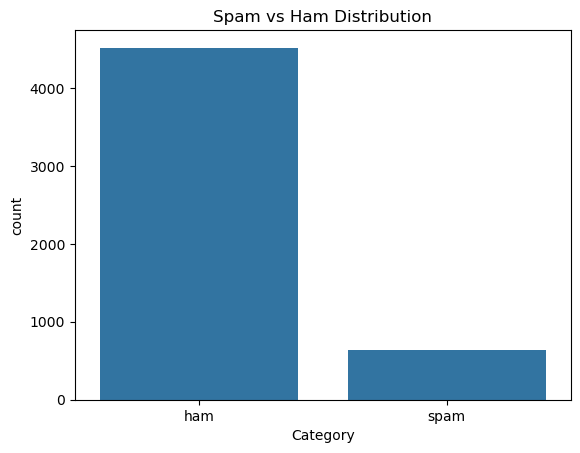

In [10]:
# Visual of dataset class distribution
sns.countplot(x = 'Category', data = df)
plt.title("Spam vs Ham Distribution")
plt.show()

##### Class Distribution Analysis

- The dataset is highly imbalanced:
  - Ham messages: 4516 (~87%)
  - Spam messages: 641 (~13%)
- This imbalance can bias the model towards predicting the majority class (ham).
- Therefore, accuracy alone is not a reliable metric. 
  Metrics like Precision, Recall, and F1-score will be more appropriate for evaluation.

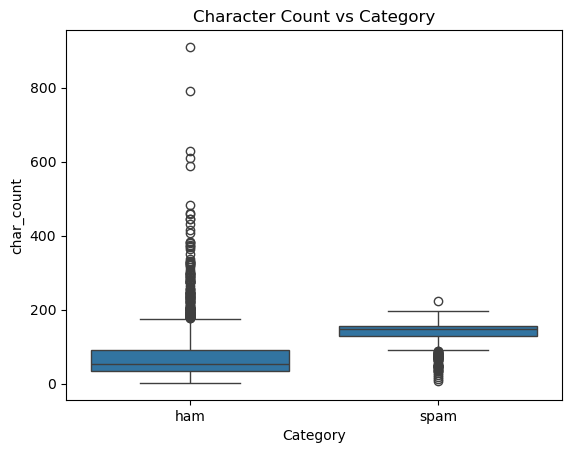

In [12]:
# Boxplot - This clearly shows difference between spam & ham
sns.boxplot(x='Category', y='char_count', data=df)
plt.title("Character Count vs Category")
plt.show()

##### Character Count vs Category
- Spam messages are generally longer, as their median character count is higher than ham.
- Ham messages are shorter on average but show high variability with many long outliers.
- Spam messages are more consistent in length, indicated by a narrower box.
- Ham contains more extreme outliers, while spam has fewer and less extreme ones.

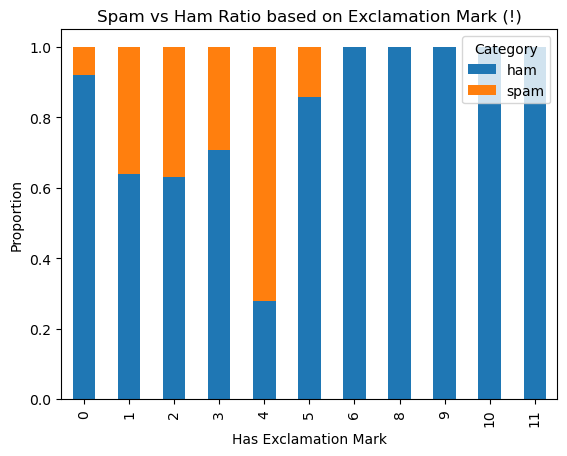

In [13]:
pd.crosstab(df['exclamation_count'], df['Category'], normalize='index').plot(
    kind='bar', stacked=True
)

plt.title("Spam vs Ham Ratio based on Exclamation Mark (!)")
plt.xlabel("Has Exclamation Mark")
plt.ylabel("Proportion")
plt.show()

##### Exclamation Mark Count vs Category
- Spam messages tend to use more exclamation marks than ham messages.
- Spam messages often include multiple “!” to create urgency or attention.
- Most ham messages contain zero or very few exclamation marks.
- The presence of exclamation marks is more common in spam compared to ham.
- So, exclamation mark usage can help in identifying spam messages.

In [14]:
# Label Encoding
df['Category'] = df['Category'].map({'ham': 0, 'spam': 1})

# Drop any NaN after mapping
df = df.dropna()

# Now generate spam text
spam_text = " ".join(df[df['Category'] == 1]['Message'].astype(str))

print(len(spam_text)) 

88533


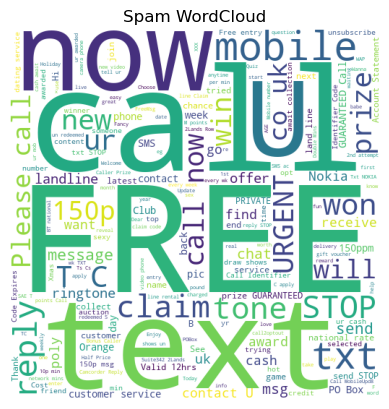

In [15]:
# Load mask image
mask = np.array(Image.open("C:\\Users\\vinit\\Downloads\\NLP Module\\Projects\\Spam & Ham Project\\mask.png"))

# Generate wordcloud
wc = WordCloud(
    background_color='white',
    mask=mask   
).generate(spam_text)

plt.imshow(wc)
plt.axis('off')
plt.title("Spam WordCloud")
plt.show()

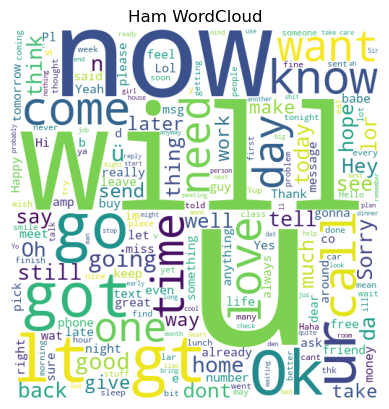

In [16]:
# Create ham text
ham_text = " ".join(df[df['Category'] == 0]['Message'].astype(str))

# Generate wordcloud
wc_ham = WordCloud(
    background_color='white',
    mask=mask,
    contour_width=1,
    contour_color='black'
).generate(ham_text)

# Display
plt.imshow(wc_ham)
plt.axis('off')
plt.title("Ham WordCloud")
plt.show()

##### WordCloud Visualization
- WordCloud is used to show the most frequent words in the messages.
- A custom shape (mask) is used to make the visualization more attractive.
- In spam messages, words like "free", "text", and "call" appear more often.
- In ham messages, common daily conversation words are more frequent.
- This helps to easily understand the difference between spam and normal messages.

**Text Preprocessing**

In [17]:
# Download Required Data
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize Tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Preprocessing Function
def preprocess_text(text):
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove stopwords + lemmatizing
    words = [
        lemmatizer.lemmatize(word)
        for word in text.split()
        if word.isalpha() and word not in stop_words
    ]
    
    return " ".join(words)

# 5. Apply Function
df['clean_text'] = df['Message'].apply(preprocess_text)

# 6. Final Output
df[['Message', 'clean_text']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vinit\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\vinit\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,Message,clean_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts may...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though


##### Text Preprocessing
- Converted text to lowercase.
- Removed punctuation from messages.
- Tokenized the text into words using split().
- Removed stopwords (common words like "the", "is").
- Applied Lemmatization to reduce words to their root form.

After text preprocessing:
- The text becomes clean, consistent, and noise-free
- All messages are converted into a standard format (clean_text)
- Irrelevant words (stopwords, punctuation) are removed
- Words are reduced to a smaller vocabulary size
- The dataset becomes suitable for feature extraction techniques like TF-IDF or Bag of Words
- Machine learning models can now convert text into numerical vectors for training
- Overall model performance improves due to reduced noise and better patterns

In [18]:
# Train-Test Split
X = df['clean_text']
y = df['Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Model Building**

In [19]:
# Logistic Regression Pipeline
lr_model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ('clf', LogisticRegression(class_weight='balanced'))
])

lr_model.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [20]:
# Naive Bayes Pipeline
nb_model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ('clf', MultinomialNB())
])

nb_model.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [21]:
# SVM Pipeline
svm_model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ('clf', LinearSVC(class_weight='balanced'))
])

svm_model.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [22]:
# Predictions
y_pred_lr = lr_model.predict(X_test)
y_pred_nb = nb_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)

**Model Evaluation**

In [23]:
print("Classification Report of Logistic Regression:\n")
print(classification_report(y_test, y_pred_lr))

Classification Report of Logistic Regression:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       904
           1       0.85      0.87      0.86       128

    accuracy                           0.97      1032
   macro avg       0.92      0.92      0.92      1032
weighted avg       0.97      0.97      0.97      1032



In [24]:
print("Classification Report of Naive Bayes:\n")
print(classification_report(y_test, y_pred_nb))

Classification Report of Naive Bayes:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       904
           1       1.00      0.73      0.84       128

    accuracy                           0.97      1032
   macro avg       0.98      0.86      0.91      1032
weighted avg       0.97      0.97      0.96      1032



In [25]:
print("Classification Report of SVM:\n")
print(classification_report(y_test, y_pred_svm))

Classification Report of SVM:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       904
           1       0.88      0.86      0.87       128

    accuracy                           0.97      1032
   macro avg       0.93      0.92      0.93      1032
weighted avg       0.97      0.97      0.97      1032



In [26]:
print("ROC-AUC of Logistic Regression:")
y_prob = lr_model.predict_proba(X_test)[:, 1]
roc_auc_score(y_test, y_prob)

ROC-AUC of Logistic Regression:


0.9850922981194691

In [27]:
print("ROC-AUC of SVM:")
y_score = svm_model.decision_function(X_test)
roc_auc_score(y_test, y_score)

ROC-AUC of SVM:


0.9859997234513275

In [28]:
print("Confusion Matrix of Logistic Regression:\n")
print(confusion_matrix(y_test, y_pred_lr))

Confusion Matrix of Logistic Regression:

[[885  19]
 [ 17 111]]


In [29]:
print("Confusion Matrix of Naive Bayes:\n")
print(confusion_matrix(y_test, y_pred_nb))

Confusion Matrix of Naive Bayes:

[[904   0]
 [ 35  93]]


In [30]:
print("Confusion Matrix of SVM:\n")
print(confusion_matrix(y_test, y_pred_svm))

Confusion Matrix of SVM:

[[889  15]
 [ 18 110]]


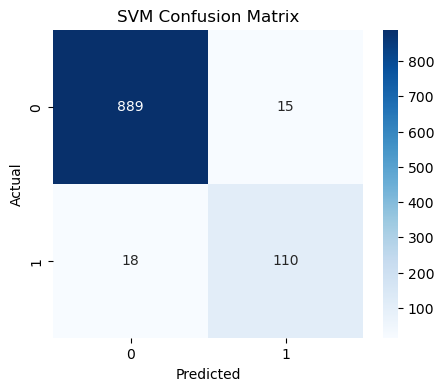

In [31]:
# Confusion matrix visualization
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    
    plt.show()
plot_confusion_matrix(y_test, y_pred_svm, "SVM Confusion Matrix")

In [32]:
# Cross-Validation
scores = cross_val_score(
    svm_model,
    X,
    y,
    cv=5,
    scoring='f1'
)

print("Cross-validation F1 scores:", scores)
print("Mean F1 score:", scores.mean())
print("Standard deviation:", scores.std())

Cross-validation F1 scores: [0.8984375  0.89711934 0.89795918 0.88888889 0.88537549]
Mean F1 score: 0.8935560816394581
Standard deviation: 0.005378049370443827


In [33]:
# Error Analysis
mistakes = pd.DataFrame({
    "Text": X_test,
    "Actual": y_test,
    "Predicted": y_pred_svm
})
mistakes[mistakes["Actual"] != mistakes["Predicted"]].head()

,Text,Actual,Predicted
4016,receiving week triple echo ringtone shortly enjoy,1,0
3692,sir waiting call free please call,0,1
4729,career tel added u contact indyarockscom send ...,0,1
4360,ü send content page,0,1
3864,oh god ive found number im glad text back xaft...,1,0


**Saved the best model**

In [34]:
# Saving the best model
import pickle

pickle.dump(svm_model, open("model.pkl", "wb"))

**Project Summary: Spam vs Ham Classification (NLP)**

#### 1. Introduction

This project focuses on building a Natural Language Processing (NLP) system to classify SMS messages into two categories: Spam and Ham (Not Spam). The objective is to automatically detect unwanted messages using machine learning techniques and improve message filtering systems.

#### 2. Data Understanding and Cleaning
- The dataset contains 5572 SMS messages with two columns: Category and Message. There were no missing values, but 415 duplicate records were
  removed to improve data quality.
- The target variable consists of two classes: ham and spam, with a noticeable class imbalance where ham messages are more dominant.

#### 3. Exploratory Data Analysis (EDA)

During EDA, additional features such as character count, word count, and exclamation mark count were created to better understand message patterns.

Key insights:
- Spam messages are generally longer than ham messages.
- Spam messages contain more exclamation marks, indicating urgency or promotion.
- WordCloud visualization highlighted spam-related words like “free”, “call”, and “text”.
- Ham messages contained more conversational vocabulary.

These insights helped identify meaningful patterns for classification. Confusion matrix heatmaps were also used to evaluate model performance by analyzing true positives, true negatives, false positives, and false negatives.

#### 4. Text Preprocessing

Text preprocessing was performed to clean and standardize the messages:
- Converted text to lowercase
- Removed punctuation and stopwords
- Applied lemmatization using WordNetLemmatizer
- Retained only alphabetic tokens

The cleaned text was stored in a new column called clean_text, improving feature quality for modeling. A pipeline-based approach was used to ensure structured workflow and prevent data leakage.

#### 5. Feature Engineering (Vectorization)

The cleaned text was converted into numerical features using TF-IDF Vectorization with:
- Maximum 5000 features
- Unigrams and bigrams (1,2)

This helped capture both individual words and meaningful word combinations, improving contextual understanding while maintaining efficiency.

#### 6. Model Building

Three machine learning models were implemented using a Pipeline approach (TF-IDF + classifier combined):
- Logistic Regression (class_weight='balanced')
- Multinomial Naive Bayes
- LinearSVC (Linear Support Vector Classifier) with class balancing

Using a pipeline ensured:
- No manual feature transformation
- No data leakage
- Production-ready workflow

This approach also improved handling of class imbalance and ensured consistent preprocessing during training and prediction.

#### 7. Model Evaluation

Models were evaluated using precision, recall, F1-score, confusion matrix, and ROC-AUC score, focusing on F1-score due to class imbalance.

Best Model: LinearSVC (Linear Support Vector Classifier)

Performance:
- Precision, Recall, F1-score ≈ 0.98
- ROC-AUC Score ≈ 0.9859

This model provided the best balance between spam and ham classification.

Cross-Validation Results:

To ensure model stability, 5-fold cross-validation was performed using F1-score:
- Mean F1 Score: 0.8935
- Standard Deviation: 0.0053

This indicates consistent and reliable model performance across different data splits.

#### 8. Error Analysis

Misclassified messages were analyzed from the test set. Errors mainly occurred in:
- Short spam messages
- Ham messages containing spam-like words

This helped identify edge cases and limitations of the model.

#### 9. Model Saving

The final model selected was LinearSVC pipeline, saved using pickle as model.pkl.

Since TF-IDF and classifier are combined in a single pipeline, both preprocessing and prediction steps are stored together. This ensures:
- No separate vectorizer required
- Direct prediction from raw input
- Fully deployment-ready system
- 
#### 10. Model Deployment 
The trained model was deployed using Streamlit on Hugging Face Spaces.

Steps:
- Streamlit app (app.py) created for user input
- Saved pipeline model (model.pkl) loaded in the app
- User SMS text is directly passed to the model
- Prediction displayed as Spam or Ham in real time

Since TF-IDF and classifier are integrated in a pipeline, preprocessing and prediction happen automatically during inference.

#### 10. Conclusion
- This project successfully demonstrates a complete end-to-end NLP pipeline for spam detection, including data cleaning, EDA, preprocessing, feature
  engineering, model training, evaluation, and deployment.
- The use of lemmatization, bigram TF-IDF features, and LinearSVC (Linear Support Vector Classifier) significantly improved model performance.
- The final system is deployed as a real-time web application, making it practical and ready for real-world usage.
- This solution can be applied in SMS filtering, email classification, and fraud message detection systems, improving user security and
  communication efficiency.